In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv("../data/processed/feature_data.csv")

In [20]:
data['session'].nunique()

2

Number of invocations per sessions - some stats

In [21]:
data[['session', 'tid']].groupby('session').count().min(), data[['session', 'tid']].groupby('session').count().max(), data[['session', 'tid']].groupby('session').count().mean()

(tid    1188
 dtype: int64,
 tid    1492
 dtype: int64,
 tid    1340.0
 dtype: float64)

E2E time distribution

avg e2e times 1.216 seconds


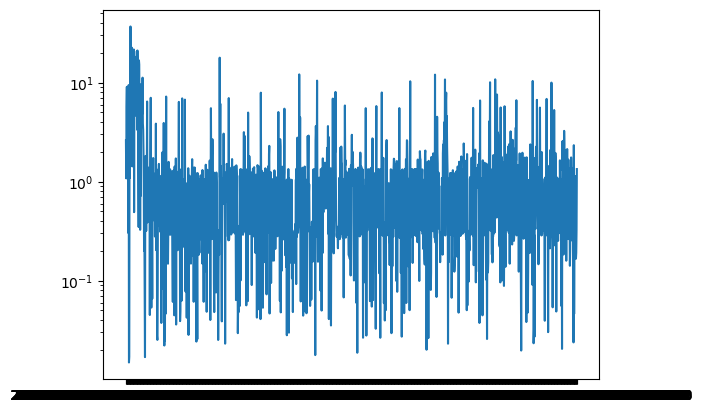

In [22]:
session = 0
session_data = data[data['session'] == session].sort_values(by='invocation_timestamp').reset_index(drop=True)
print(f"avg e2e times {round(session_data['e2etime'].mean(), 3)} seconds")
plt.figure()
plt.plot(session_data['invocation_timestamp'].values, session_data['e2etime'].values)
plt.yscale('log')  # Latency is best viewed on a log scale
plt.show()

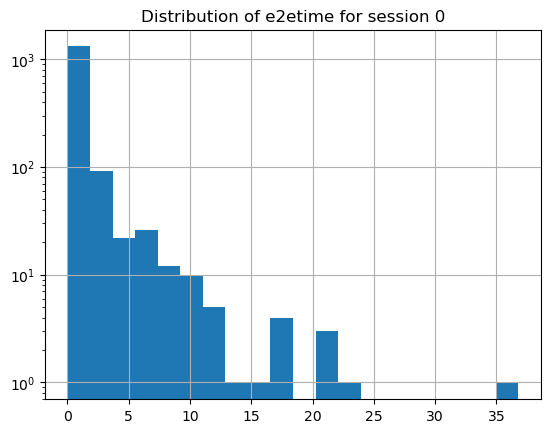

In [23]:
plt.figure()
session_data['e2etime'].hist(bins=20)
plt.title(f"Distribution of e2etime for session {session}")
plt.yscale('log')
plt.show()

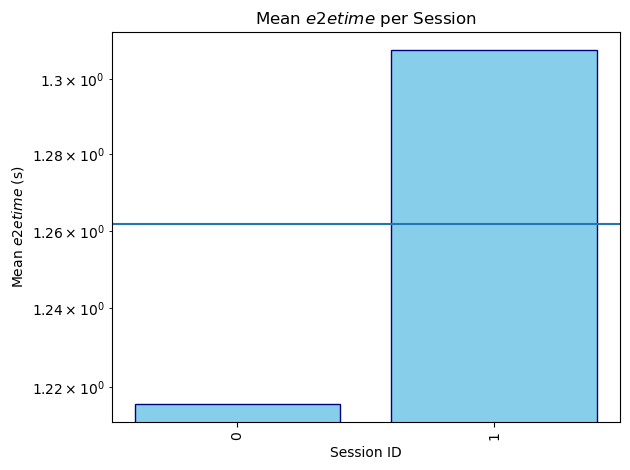

In [24]:
def get_session_stats(df, session_col='session', value_col='e2etime'):
    """
    Calculates the mean value per session and ensures the data is sorted.
    """
    # Group by session and calculate mean
    stats = df.groupby(session_col)[value_col].mean().reset_index()
    
    # Sort by session id to ensure a logical order on the x-axis
    stats = stats.sort_values(session_col)
    return stats

def plot_mean_latency(stats, session_col='session', value_col='e2etime', save_path='session_latency(log).png'):
    """
    Creates a bar plot for mean latency per session.
    """
    # 1. Setup plot labels and aesthetics
    # Convert session IDs to strings for categorical-style x-axis spacing
    x_labels = stats[session_col].astype(str)
    y_values = stats[value_col]

    plt.bar(x_labels, y_values, color='skyblue', edgecolor='navy')
    
    # 2. Formatting
    plt.title('Mean $e2etime$ per Session')
    plt.xlabel('Session ID')
    plt.ylabel('Mean $e2etime$ (s)')
    plt.yscale('log')
    plt.axhline(y_values.mean())
    # Rotate labels if you have many sessions
    plt.xticks(rotation=90)
    
    # Add a grid for easier reading of values
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 3. Finalize
    plt.tight_layout()
    plt.savefig(save_path)

session_stats = get_session_stats(data)
plot_mean_latency(session_stats)

### Few sessions data looks suspicious. Removing it before further analysis

In [25]:
bad_sessions = [ 21,  20, 162,  14, 163, 160, 167]

In [12]:
data = data[data['session'].isin(bad_sessions) == False].reset_index(drop=True)

Effect of fqdn on e2e time - Does fqdn affect?

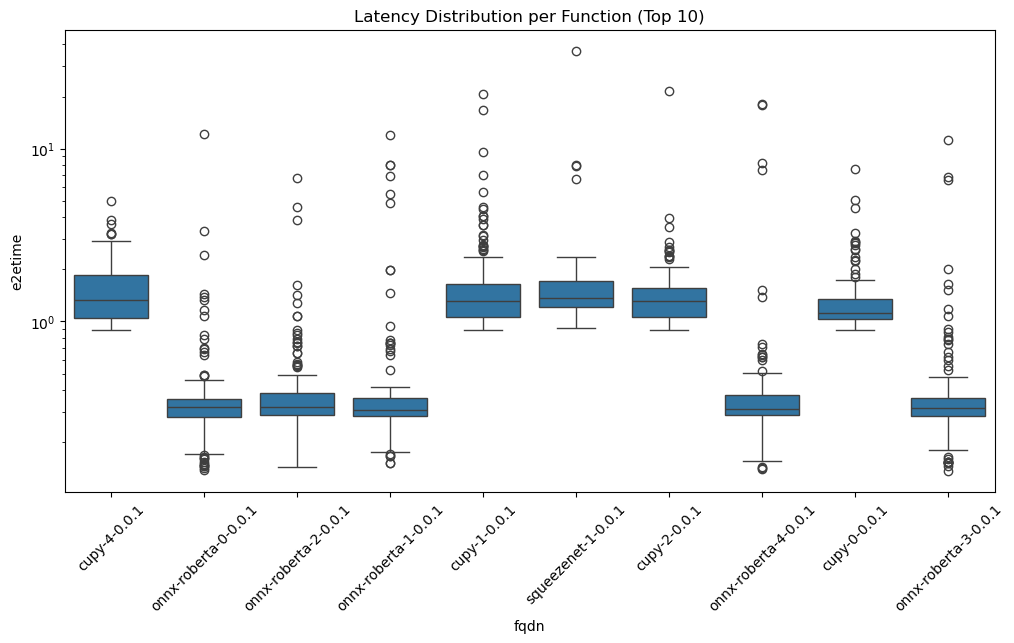

In [13]:
top_functions = session_data['fqdn'].value_counts().nlargest(10).index
subset = session_data[session_data['fqdn'].isin(top_functions)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='fqdn', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per Function (Top 10)")
plt.show()

GPU representation - Looking at two features here:
1. `num_running_funcs_filled` - Effect of number of functions running currently on e2etime
2. `is_cold_start` - a binary flag that indicate whether the execution is going to be a cold start or not

Number of functions running currently at the time of invocation

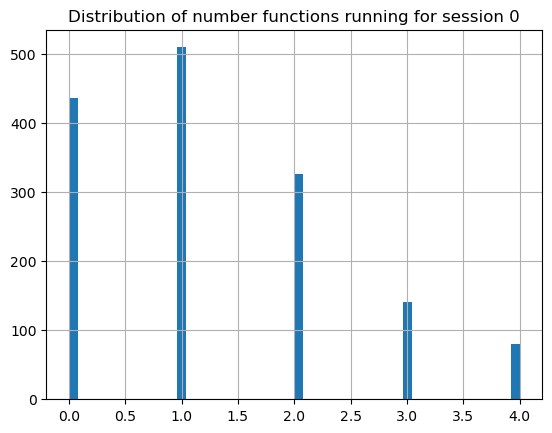

In [14]:
plt.figure()
session_data['num_running_funcs_filled'].hist(bins=50)
plt.title(f"Distribution of number functions running for session {session}")
plt.show()

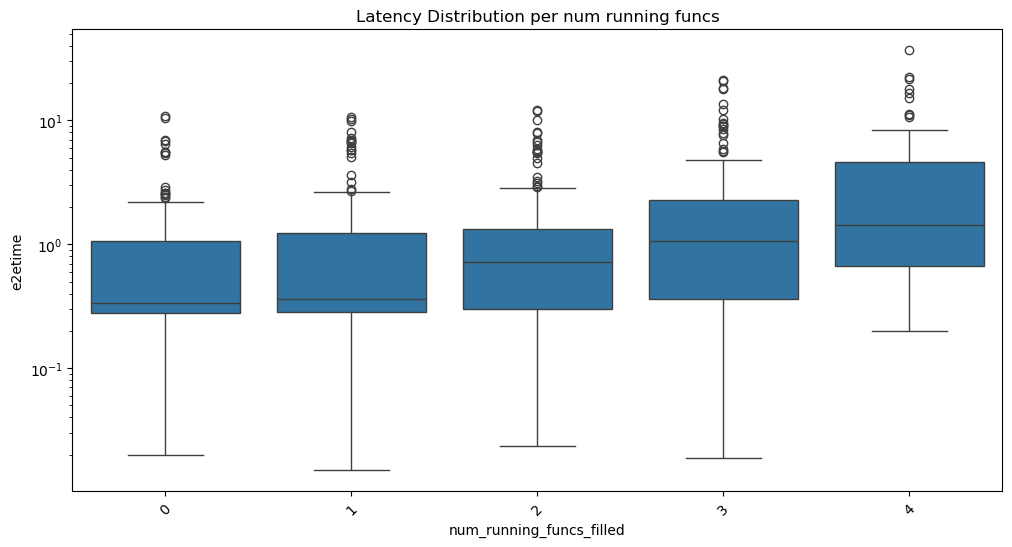

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=session_data, x='num_running_funcs_filled', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per num running funcs")
plt.show()

is_cold_start

In [26]:
session_data['is_cold_start'].value_counts()

is_cold_start
0    1430
1      62
Name: count, dtype: int64

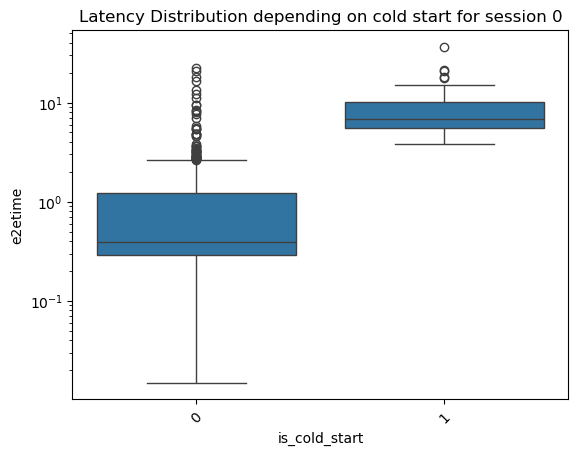

In [27]:
plt.figure()
sns.boxplot(data=session_data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title(f"Latency Distribution depending on cold start for session {session}")
plt.show()

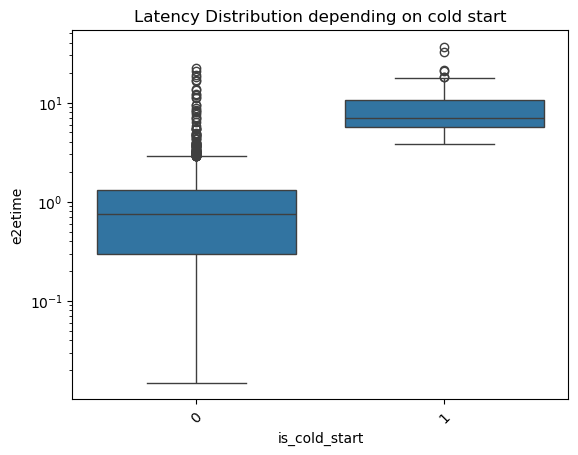

In [28]:
plt.figure()
sns.boxplot(data=data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution depending on cold start")
plt.show()

Queue length stats - Here, we look at 2 features
1. `target_queue_len` - queue length of the incoming fqdn
2. `others_len_queue` - sum of queue lengths of all fqdn queue lengths except the incoming fqdn

In [29]:
data['target_queue_len'].value_counts()

target_queue_len
0.0    2664
1.0      16
Name: count, dtype: int64

In [30]:
data['others_len_queue'].value_counts()

others_len_queue
0.0    2513
1.0      87
2.0      39
3.0      20
4.0       6
5.0       6
6.0       6
7.0       2
8.0       1
Name: count, dtype: int64

Correlation between `target_queue_len` and `e2etime`

In [31]:
(session_data['target_queue_len']).corr(session_data['e2etime']), (data['target_queue_len']).corr(data['e2etime']) 

(0.10400106717358255, 0.08668146662471762)

In [32]:
(session_data['others_len_queue']).corr(session_data['e2etime']), (data['others_len_queue']).corr(data['e2etime']) 

(0.46392587408911945, 0.46761293015505095)

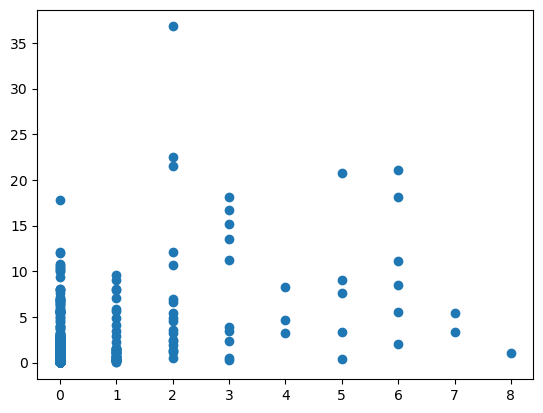

In [33]:
plt.figure()
plt.scatter(session_data['others_len_queue'], session_data['e2etime'])
plt.show()

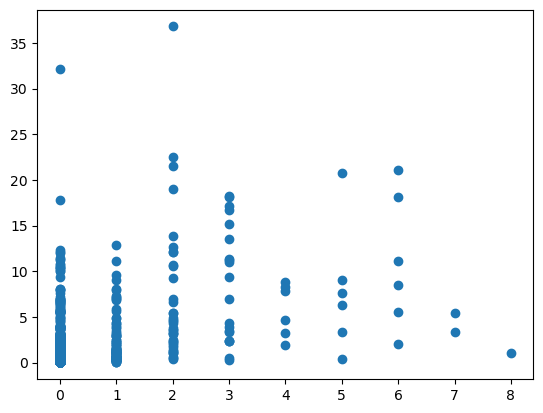

In [34]:
plt.figure()
plt.scatter(data['others_len_queue'], data['e2etime'])
plt.show()

In [43]:
base_cols = [
            'target_queue_len', 'others_len_queue', 'iat_fqdn', 'num_running_funcs_filled',
            'gpu_warm_results_sec', 'gpu_cold_results_sec', 'is_cold_start'
        ]
data[base_cols+['e2etime']].corr()

,target_queue_len,others_len_queue,iat_fqdn,num_running_funcs_filled,gpu_warm_results_sec,gpu_cold_results_sec,is_cold_start,e2etime
target_queue_len,1.000000,0.213506,-0.028125,0.118303,-0.032562,-0.021633,0.012214,0.086681
others_len_queue,0.213506,1.000000,-0.032604,0.380160,-0.051471,0.083890,0.170122,0.467613
iat_fqdn,-0.028125,-0.032604,1.000000,-0.015338,-0.021358,0.247534,0.246672,0.094281
num_running_funcs_filled,0.118303,0.380160,-0.015338,1.000000,-0.003217,0.060044,0.161033,0.314493
gpu_warm_results_sec,-0.032562,-0.051471,-0.021358,-0.003217,1.000000,-0.037055,-0.006983,0.163838
gpu_cold_results_sec,-0.021633,0.083890,0.247534,0.060044,-0.037055,1.000000,0.125744,0.163250
is_cold_start,0.012214,0.170122,0.246672,0.161033,-0.006983,0.125744,1.000000,0.642875
e2etime,0.086681,0.467613,0.094281,0.314493,0.163838,0.163250,0.642875,1.000000
